# Budget sweep — read-only

Every number here comes from `<run>/seed_*/<arm>/summary.json`. Nothing is refitted and nothing
is rescored, so this notebook runs in seconds and cannot disagree with the sweep that produced
the data.

`compare_all_methods.ipynb` writes all of it: infidelity, SPAM, diamond distance and the
accounted shot budget, for the POUNDERS arms and the LM arms alike. Diamond distance needs
cvxpy + cvxopt **in the environment that runs the sweep** — not here.

Arms are discovered from the folder names, so anything the sweep adds later shows up without
editing this notebook.

**Gone from the old version:** `adaptive_D + polish`, `LM MLE (standalone)` and `LM + FPR` used
to be fitted here. The last two are now real arms (`lm_mle`, `lm_fpr`) written by the sweep. The
polish is not — it was a post-hoc refit on a redrawn dataset, and the inline LM checkpoints
(`lm_checkpoints.csv`, `LM_CKPT_ENABLED`) answer the same question on the data POUNDERS actually
measured.

In [27]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DIR = Path.cwd()                       # run from seed_sweep_experiments
warnings.filterwarnings("ignore")

# summary.json keys -> the short column names used below
INF_KEY   = "mean_gate_entanglement_infidelity_to_truth"
DD_KEY    = "mean_gate_diamond_distance_to_truth"
SPAM_KEY  = "mean_spam_vector_l2_error_to_truth"
SHOTS_KEY = "accounted_revealed_shots"

# None = every seed folder on disk; a list restricts to those seeds. Unequal n across budgets
# is fine -- the plots take a median per run folder, so it only means some medians are better
# estimated. Discarding folders to balance n throws away real data.
SEEDS = None

# Restrict to arms that fit on the FULL circuit design, dropping the FPR-reduced ones
# (fixed_fpr ~819 circuits, adaptive_D ~833, lm_fpr ~442 of 1918). With those gone every
# remaining arm sees the same 1918 circuits, so a difference between them is a difference in
# ALLOCATION and nothing else -- the FPR arms confound allocation with circuit selection, and
# we already know the reduction costs more than the allocation gains.
#
# The test is on the data (revealed_circuits == total_circuits), not a list of arm names, so
# a new FPR variant is excluded without editing this and a new full-design arm is included.
FULL_CIRCUITS_ONLY = True

RUN_GLOB = "all_methods_comparison*"
RUNS = [r for r in sorted(DIR.glob(RUN_GLOB)) if r.is_dir()]


def seed_dirs(run):
    """The run's seed folders; all of them when SEEDS is None."""
    return [sd for sd in sorted(run.glob("seed_*"))
            if SEEDS is None or int(sd.name.split("_")[1]) in SEEDS]


def _num(d, key):
    """summary.json value as a float, with a missing or null key becoming NaN."""
    v = d.get(key)
    try:
        return float(v)
    except (TypeError, ValueError):
        return float("nan")


def _from_trajectory(arm, summ, keys):
    """Backfill metrics an older arm did not write into summary.json.

    The LM arms write lm_trajectory.csv with one row per max-length stage, and the LAST row is
    the final estimate. Only trust it when its infidelity matches summary.json -- that proves
    the two describe the same model rather than a stale file."""
    traj = arm / "lm_trajectory.csv"
    if not traj.exists() or not any(k not in summ for k in keys):
        return {}
    try:
        t = pd.read_csv(traj)
    except Exception:
        return {}
    if t.empty:
        return {}
    last = t.iloc[-1]
    if INF_KEY in t.columns and INF_KEY in summ:
        if abs(last[INF_KEY] - summ[INF_KEY]) > 1e-9 * max(abs(summ[INF_KEY]), 1e-30):
            return {}
    return {k: last[k] for k in keys if k not in summ and k in t.columns}


def load():
    """One row per (run folder, seed, arm), straight from summary.json.

    Arms are whatever subdirectories carry a summary.json, so a new arm in the sweep needs no
    change here. `objective` records which residual the arm minimised (weighted_least_squares
    vs poisson_logl for POUNDERS, chi2_ladder_then_mle vs pure_mle for the LM arms) so WLS and
    logl sweeps can be told apart if they share a folder."""
    rows = []
    for run in RUNS:
        for sd in seed_dirs(run):
            for arm in sorted(p for p in sd.iterdir() if p.is_dir()):
                f = arm / "summary.json"
                if not f.exists():
                    continue
                s = json.loads(f.read_text())
                s = {**_from_trajectory(arm, s, (INF_KEY, DD_KEY, SPAM_KEY)), **s}
                rows.append(dict(run=run.name, seed=int(sd.name.split("_")[1]),
                                 method=arm.name,
                                 shots=_num(s, SHOTS_KEY),
                                 infidelity=_num(s, INF_KEY),
                                 diamond=_num(s, DD_KEY),
                                 spam=_num(s, SPAM_KEY),
                                 circuits=_num(s, "revealed_circuits"),
                                 total_circuits=_num(s, "total_circuits"),
                                 objective=s.get("objective_mode") or s.get("objective")))
    return pd.DataFrame(rows)


df = load()
if df.empty:
    raise FileNotFoundError(
        f"No summary.json under {DIR}/{RUN_GLOB}/seed_*/*/ . Run compare_all_methods first.")

if FULL_CIRCUITS_ONLY:
    # nunique over the ratio, per arm: an arm counts as full-design only if EVERY run of it
    # revealed every circuit. An arm that is full in one budget and reduced in another would
    # otherwise be pooled across two different designs.
    frac = df.groupby("method").apply(
        lambda g: (g["circuits"] / g["total_circuits"]).min(), include_groups=False)
    full = set(frac[frac >= 1.0 - 1e-9].index)
    dropped = sorted(set(df["method"]) - full)
    if dropped:
        _d = df[df["method"].isin(dropped)].groupby("method")["circuits"].median()
        print("FULL_CIRCUITS_ONLY -- dropped " + ", ".join(
            f"{m} ({int(_d[m])} circ)" for m in dropped))
    df = df[df["method"].isin(full)].reset_index(drop=True)
    if df.empty:
        raise ValueError("FULL_CIRCUITS_ONLY removed every arm -- check revealed_circuits")
    print()

for r in RUNS:
    print(f"{r.name}: {len(seed_dirs(r))} of {len(list(r.glob('seed_*')))} seed folders")
print()
print(df.groupby("method").agg(
    rows=("seed", "size"), seeds=("seed", "nunique"), budgets=("run", "nunique"),
    with_diamond=("diamond", lambda v: int(v.notna().sum())),
    with_spam=("spam", lambda v: int(v.notna().sum())),
    objective=("objective", lambda v: "/".join(sorted(set(v.dropna())) or ["-"]))
).to_string())

_missing = df.groupby("method")["diamond"].apply(lambda v: v.isna().all())
if _missing.any():
    print("\nno diamond distance for: " + ", ".join(_missing[_missing].index) +
          "\n  -> those runs predate report_diamond_distance, or the sweep environment "
          "lacked cvxpy/cvxopt. Re-run them to fill it in.")

FULL_CIRCUITS_ONLY -- dropped adaptive_D (892 circ), fixed_fpr (839 circ), lm_fpr (442 circ)

all_methods_comparison_1000: 3 of 3 seed folders
all_methods_comparison_500: 3 of 3 seed folders

                       rows  seeds  budgets  with_diamond  with_spam             objective
method                                                                                    
adaptive_D_nofpr          6      3        2             6          6          poisson_logl
adaptive_D_nofpr_f010     3      3        1             3          3          poisson_logl
adaptive_D_nofpr_f020     3      3        1             3          3          poisson_logl
adaptive_D_nofpr_f030     3      3        1             3          3          poisson_logl
adaptive_D_nofpr_f040     3      3        1             3          3          poisson_logl
adaptive_D_nofpr_f050     3      3        1             3          3          poisson_logl
adaptive_D_nofpr_f060     3      3        1             3          3          po

## Gauge-free metrics

`infidelity`, `diamond` and `spam` above are all computed AFTER `gaugeopt_to_target`, so every
one of them depends on `gaugeopt_spam_weight` -- a knob set in the config, not measured. On seed
101 sweeping that weight from 0.1 to 10 moves infidelity by 3.2x, SPAM by 4x and diamond by 1.5x,
without refitting anything. A comparison between arms can therefore be argued with by pointing
at the weight.

Gauge acts on gates by conjugation, `G -> S G S^-1`, so a gate's EIGENVALUES do not move. The
two metrics below are built from eigenvalues and need no gauge fixing at all:

- `ev_diamond` (`eigenvalue_diamondnorm`) -- `(d2-1)/d2 * max|evA - evB|` over matched pairs.
  Zero for a perfect estimate, sensitive to both rotation-angle and decay error. **Prefer this.**
- `ev_diamond_nu` (`eigenvalue_nonunitary_diamondnorm`) -- matches on `||evA| - |evB||`, so it
  sees decay error only and is blind to rotation-angle error. A partial view, kept because it
  separates the arms more sharply.

Two pyGSTi eigenvalue metrics are deliberately NOT used:

- `eigenvalue_entanglement_infidelity` reads **9.05e-03 for a perfect estimate** on this truth
  model (it sums `conj(evB)*evA`, which is `sum|ev|^2 < d2` for any non-unitary gate). Its
  floor is ~7.6e-03 while real estimation error is ~1e-05, so the number is >99% floor and
  ranks every arm the same. `eigenvalue_avg_gate_infidelity` has the same flaw (floor 5.1e-03).
- `eigenvalue_nonunitary_entanglement_infidelity` divides that floor out but is **signed**:
  `(d2-1)/d2 * (1 - sqrt(U))` goes negative whenever the estimate is LESS decoherent than the
  truth, which it does here (`adaptive_D` reads -8.0e-06). It says which way the estimate
  misses, not how far. Never average it or take a ratio of it.

CAVEAT: these compare each gate's spectrum separately, so they miss error in how the gates
relate to EACH OTHER -- a gauge is one common `S` for the whole set, and per-gate spectral
agreement does not imply such an `S` exists. Read them as a gauge-free LOWER BOUND on the
error, not as the error itself.

`spam_tracedist` replaces the old L2 SPAM column in the plots. It follows pyGSTi's own report
conventions: trace distance between density matrices for the prep (`vec_trace_diff`), and the
Jamiolkowski trace distance for the POVM treated as a map from states to outcomes
(`povm_jtracedist`) -- a single effect is not a density matrix, so trace distance applies to
the POVM as a whole, not per outcome. Unlike the L2 norm it is basis-independent and equals the
largest probability difference any measurement could produce. It is **still gauge-dependent**;
that is unfixable, since gauge acts one-sidedly on preps and effects. The old
`spam` (L2) column is still in `df` if you want to compare.

Values are cached in `<run>/recomputed_metrics.csv`. The first run over a new sweep computes
them from `x_best.npy` (no refitting, no gauge optimisation -- seconds per seed); after that
the cell just reads the CSV and the notebook stays fast.


In [28]:
# Post-hoc metrics recomputed from x_best.npy and cached per run folder.
#
#   ev_diamond / ev_diamond_nu   gauge-free gate error       (no gauge, no truth-free)
#   spam_tracedist               SPAM error as trace distance
#   nongauge_*                   Fisher covariance on the identifiable subspace
#   oos_2dlogl                   out-of-sample 2*deltaLogL on a fresh common dataset
#
# Nothing is refitted; x_best.npy is the parameter vector. Cost is ~2.5s per arm (one gauge
# optimisation, one Jacobian, one dataset scoring), paid once and cached.
METRIC_CACHE = "recomputed_metrics.csv"
OUT_COLS = ["ev_diamond", "ev_diamond_nu", "spam_tracedist",
            "nongauge_logdet", "nongauge_gen_var", "nongauge_trace_inv", "nongauge_rank",
            "oos_2dlogl"]

# Number of top Fisher eigenvalues the design metrics are computed over.
#
# This is a CONVENTION, not a discovered dimension, and it has to be pinned or the numbers
# are not comparable between arms. Two facts force that:
#   * pyGSTi reports 13 nongauge / 59 gauge params for this CPTPLND model, but the empirical
#     Fisher information has ~41 directions above adaptive_shots.RANK_CUTOFF. The two
#     disagree by a lot.
#   * The spectrum has NO clean gap -- it decays smoothly through 1e1, 1e0, 1e-2, 1e-5 -- so
#     a relative cutoff lands at a different index for each arm (39 to 43 across these runs).
#     logdet would then be a sum over a different number of eigenvalues per arm.
# Fixing K makes every arm a sum over the same-indexed directions.
#
# Verified: the ARM ORDERING is stable for K in 20..43 (Spearman 0.92-1.00 against K=40, with
# the three LM-family arms last at every K). The absolute value is not -- it moves ~2 decades
# across that range -- so compare gen_var between arms, never quote it as an absolute variance.
NONGAUGE_K = 40

EVAL_SHOTS = 400          # uniform shots/circuit in the fresh evaluation dataset
EVAL_SEED_OFFSET = 10_000_000   # keeps the eval draw disjoint from any fit data seed


def _eig_metrics(model, truth):
    """Gauge-free eigenvalue distances only -- no gauge optimisation. Used by the
    sensitivity cell below, where the whole point is to avoid fixing a gauge."""
    from pygsti.report.reportables import (
        eigenvalue_diamondnorm as _dn,
        eigenvalue_nonunitary_diamondnorm as _dnu,
    )
    m = model.copy(); m.set_all_parameterizations("full")
    t = truth.copy(); t.set_all_parameterizations("full")
    dn, dnu = [], []
    for lab in t.operations.keys():
        a = np.asarray(m.operations[lab].to_dense())
        b = np.asarray(t.operations[lab].to_dense())
        dn.append(float(_dn(a, b, t.basis)))
        dnu.append(float(_dnu(a, b, t.basis)))
    return float(np.mean(dn)), float(np.mean(dnu))


def _shot_vector(arm_dir, summ, n_circuits):
    """The arm's final shots-per-circuit.

    POUNDERS arms save it. The LM arms do not, but they allocate uniformly -- which the
    summary proves when min == max -- so it can be rebuilt exactly. Anything else returns
    None rather than a guess, because a wrong shot vector silently rescales the Fisher
    information and every design number with it."""
    f = arm_dir / "final_shots_per_circuit.npy"
    if f.exists():
        v = np.asarray(np.load(f), dtype=float).reshape(-1)
        return v if v.size == n_circuits else None
    lo, hi = summ.get("min_shots_per_circuit"), summ.get("max_shots_per_circuit")
    if lo is not None and hi is not None and lo == hi:
        return np.full(n_circuits, float(lo))
    return None


def _design_metrics(prob, x, shots, row_circuit, variance_floor):
    """Fisher information on the identifiable subspace, in the allocator's own convention."""
    from adaptive_shots import fisher_information, RANK_CUTOFF, _kept_eigenvalues
    p, J, _ = prob.model_vector_and_jacobian(x)
    sigma2 = np.maximum(p * (1.0 - p), variance_floor)
    H = fisher_information(J, shots[row_circuit] / sigma2)

    # Top-K by magnitude, same K for every arm -- see NONGAUGE_K. stable_pseudo_logdet is
    # deliberately NOT used here: it truncates at a RELATIVE cutoff, which is right for the
    # allocator (comparing allocations of one model) but lands at a different index per arm,
    # which is exactly what makes cross-arm comparison invalid.
    ev = np.linalg.eigvalsh(0.5 * (H + H.T))[::-1]
    kept = _kept_eigenvalues(H)
    rank = 0 if kept is None else int(len(kept))       # cutoff-based, reported as diagnostic
    top = ev[:NONGAUGE_K]
    if top.size < NONGAUGE_K or not np.all(np.isfinite(top)) or top.min() <= 0.0:
        return dict(nongauge_logdet=np.nan, nongauge_gen_var=np.nan,
                    nongauge_trace_inv=np.nan, nongauge_rank=rank)
    ld = float(np.sum(np.log(top)))
    return dict(nongauge_logdet=ld,
                nongauge_gen_var=float(np.exp(-ld / NONGAUGE_K)),
                nongauge_trace_inv=float(np.sum(1.0 / top)),
                nongauge_rank=rank)


def recomputed_table(run, rebuild=False):
    """Read <run>/recomputed_metrics.csv, filling in any (seed, arm) rows it lacks.

    A row counts as present only if EVERY wanted column is there and finite -- otherwise a
    cache written before a metric was added would look complete and silently leave that
    column empty for the whole run."""
    cache = run / METRIC_CACHE
    have = {}
    if cache.exists() and not rebuild:
        try:
            old = pd.read_csv(cache)
            for _, r in old.iterrows():
                if all(c in old.columns and pd.notna(r.get(c)) for c in OUT_COLS):
                    have[(int(r["seed"]), str(r["arm"]))] = {c: r[c] for c in OUT_COLS}
        except Exception as exc:
            print(f"  {run.name}: unreadable cache ({exc}); rebuilding")

    wanted = [(int(sd.name.split("_")[1]), arm)
              for sd in seed_dirs(run)
              # .name, not the Path: these become dict keys compared against the arm
              # STRINGS read back from the CSV, and a Path never equals a str -- every
              # cache lookup would miss and silently recompute the whole run.
              for arm in sorted(p.name for p in sd.iterdir()
                                if p.is_dir() and (p / "x_best.npy").exists())]
    missing = [w for w in wanted if w not in have]

    if missing:
        import sys
        for _p in (str(DIR), str(DIR.parent)):    # DIR.parent holds adaptive_shots.py
            if _p not in sys.path:
                sys.path.insert(0, _p)
        from gst_seed_experiment import ExperimentConfig, GSTProblem
        print(f"  {run.name}: computing {len(missing)} of {len(wanted)} rows "
              f"({len({s for s, _ in missing})} seeds) ...")
        for seed in sorted({s for s, _ in missing}):
            sd = run / f"seed_{seed:06d}"
            arms = [a for s, a in missing if s == seed]
            cfg = ExperimentConfig.from_json(sd / arms[0] / "config.json")
            prob = GSTProblem(cfg, data_seed=seed)

            # ONE evaluation dataset per seed, shared by every arm -- scoring each arm on
            # its own fresh draw would compare them on different test sets.
            eval_ds = prob.simulate_dataset(EVAL_SHOTS, seed=EVAL_SEED_OFFSET + seed)
            idx = {c: i for i, c in enumerate(prob.circuits)}
            _, _, labels = prob.model_vector_and_jacobian(np.load(sd / arms[0] / "x_best.npy"))
            row_circuit = np.array([idx[c] for c, _ in labels])

            for arm in arms:
                rec = {c: np.nan for c in OUT_COLS}
                try:
                    x = np.load(sd / arm / "x_best.npy")
                    model = prob.copy_model_at_x(x)
                    summ, _, _ = prob.aligned_error_metrics(model, prob.truth_model, "truth")
                    rec["ev_diamond"] = summ.get("mean_gate_eigenvalue_diamondnorm_to_truth")
                    rec["ev_diamond_nu"] = summ.get(
                        "mean_gate_eigenvalue_nonunitary_diamondnorm_to_truth")
                    rec["spam_tracedist"] = summ.get("mean_spam_tracedist_to_truth")

                    shots = _shot_vector(sd / arm, json.loads(
                        (sd / arm / "summary.json").read_text()), len(prob.circuits))
                    if shots is not None:
                        rec.update(_design_metrics(prob, x, shots, row_circuit,
                                                   cfg.variance_floor))
                    else:
                        print(f"    seed {seed} {arm}: no recoverable shot vector "
                              f"-> nongauge_* left NaN")

                    rec["oos_2dlogl"] = float(
                        prob.likelihood_diagnostics(x, data=eval_ds)["two_delta_logl"])
                except Exception as exc:
                    print(f"    seed {seed} {arm}: {type(exc).__name__}: {exc}")
                have[(seed, arm)] = rec
        out = pd.DataFrame([{"seed": s, "arm": a, **v} for (s, a), v in sorted(have.items())])
        out.to_csv(cache, index=False)
        print(f"  {run.name}: cached {len(out)} rows -> {cache.name}")

    return pd.DataFrame([{"run": run.name, "seed": s, "method": a, **v}
                         for (s, a), v in sorted(have.items())])


REBUILD_RECOMPUTED = False        # True forces a recompute, e.g. after changing a metric

_rc = pd.concat([recomputed_table(r, REBUILD_RECOMPUTED) for r in RUNS], ignore_index=True)
df = df.drop(columns=[c for c in OUT_COLS if c in df.columns])
df = df.merge(_rc[["run", "seed", "method", *OUT_COLS]],
              on=["run", "seed", "method"], how="left")

print(f"\nrecomputed coverage: {int(df['ev_diamond'].notna().sum())} of {len(df)} rows")
_r = df["nongauge_rank"].dropna().unique()
print(f"nongauge_* computed over the top K={NONGAUGE_K} Fisher eigenvalues; "
      f"rank at RANK_CUTOFF varies {sorted(int(v) for v in _r)} across arms, which is why K "
      f"is pinned" if len(_r) else "no nongauge rank computed")
print(df.groupby("method")[["spam_tracedist", "ev_diamond",
                            "nongauge_gen_var", "oos_2dlogl"]]
        .median().to_string(float_format=lambda v: f"{v:.4e}"))



recomputed coverage: 48 of 48 rows
nongauge_* computed over the top K=40 Fisher eigenvalues; rank at RANK_CUTOFF varies [39, 40, 41, 42, 43] across arms, which is why K is pinned
                       spam_tracedist  ev_diamond  nongauge_gen_var  oos_2dlogl
method                                                                         
adaptive_D_nofpr           2.1863e-03  1.3960e-04        9.2836e-07  1.8786e+03
adaptive_D_nofpr_f010      1.8330e-03  8.9696e-05        5.2888e-07  1.8724e+03
adaptive_D_nofpr_f020      1.2775e-03  1.1855e-04        4.6968e-07  1.8796e+03
adaptive_D_nofpr_f030      1.6687e-03  1.7170e-04        5.1390e-07  1.8763e+03
adaptive_D_nofpr_f040      2.0227e-03  1.7842e-04        5.6877e-07  1.8853e+03
adaptive_D_nofpr_f050      2.0587e-03  1.7478e-04        6.8595e-07  1.8661e+03
adaptive_D_nofpr_f060      1.2730e-03  2.0767e-04        6.1368e-07  1.8579e+03
adaptive_D_nofpr_f070      1.1278e-03  1.7436e-04        8.0957e-07  1.9106e+03
adaptive_D_nofpr_f08

## Estimator-quality metrics: how well determined, and how well it predicts

Everything above measures **distance to a known truth**, which needs a simulated truth model
and (except for the eigenvalue columns) a gauge choice. These two measure the estimate itself.

**`nongauge_gen_var`, `nongauge_trace_inv`, `nongauge_logdet`** -- the parameter covariance.
The Fisher information is `H = J^T diag(w) J` with `w = n_row / max(p(1-p), variance_floor)`,
assembled with the SAME `adaptive_shots.fisher_information` and the arm's own final shot
vector, so this is the criterion the allocator optimises, read back out at the solution.

`H` is singular by the gauge dimension -- moving along a gauge orbit changes no probability,
so the likelihood is flat there and the variance is infinite. `stable_pseudo_logdet` and
`stable_pseudo_trace_inv` truncate at `RANK_CUTOFF` and so work on the identifiable
(nongauge) subspace only; `nongauge_rank` reports how many directions survived, and a rank
below `72 - gauge_dim` means the cutoff ate real directions.

- `nongauge_logdet` = `log det H` on that subspace. The D-optimality objective. **Higher is better.**
- `nongauge_gen_var` = `exp(-logdet / rank)` -- generalised variance per dimension, so it has
  units of a variance and is comparable across arms. **Lower is better.** This is the readable one.
- `nongauge_trace_inv` = `Tr(H^+)` -- the A-optimality objective. **Lower is better.**

Needs no truth model and no gauge fixing, and it is computed per run rather than across seeds,
so unlike the distance metrics it is not limited by having only 3 seeds.

**`oos_2dlogl`** -- out-of-sample `2*deltaLogL`. A fresh dataset is drawn from the truth model
at uniform `EVAL_SHOTS` per circuit with a fixed seed, the SAME dataset for every arm in a
seed, and each arm's saved estimate is scored against it. **Lower is better.**

Gauge-free, because the likelihood is built from probabilities `E.G.rho` and those are gauge
invariant (the sensitivity cell below shows a probability unchanged to 0.00e+00 under a gauge
transform).

NAMING, precisely: this is **not** a train/test split over circuits. Every arm was fitted on
all 1918 circuits, so no circuit can be held out after the fact. It is an independent draw
from the same truth model -- an out-of-sample check against fresh noise, not against unseen
circuits. On real hardware you would hold out real data and this would become a true
cross-validation.


### How much does the gauge choice actually move things?

Refits nothing: one saved model, gauge-optimised three times at different
`gaugeopt_spam_weight`. The gauge-dependent metrics move; `ev_diamond` does not move at all,
including against the raw un-gauge-optimised fit. Set `GAUGE_SENSITIVITY = False` to skip it
(it is the only slow cell here -- one gauge optimisation per row).


In [29]:
GAUGE_SENSITIVITY = True
SENS_WEIGHTS = [0.1, 1.0, 10.0]
# Intersected with df below, so FULL_CIRCUITS_ONLY cannot leave this cell demonstrating
# on an arm the plots above have dropped.
SENS_ARMS = ["lm", "lm_mle", "adaptive_D_nofpr_f010", "adaptive_D_nofpr"]

if GAUGE_SENSITIVITY:
    import sys
    from dataclasses import replace
    if str(DIR) not in sys.path:
        sys.path.insert(0, str(DIR))
    from gst_seed_experiment import ExperimentConfig, GSTProblem

    # the run carrying the most of SENS_ARMS, not just the last one -- a budget folder that
    # lacks the arms being compared would demonstrate the point on the wrong pair
    _kept = set(df["method"])
    _run = max(RUNS, key=lambda r: (sum((sd / a / "x_best.npy").exists()
                                        for sd in seed_dirs(r)
                                        for a in SENS_ARMS if a in _kept), r.name))
    _sds = seed_dirs(_run)
    if not _sds:
        print("no seed folders to demonstrate on")
    else:
        _sd = _sds[0]
        _seed = int(_sd.name.split("_")[1])
        _arms = [a for a in SENS_ARMS
                 if a in _kept and (_sd / a / "x_best.npy").exists()]
        if not _arms:
            print(f"none of {SENS_ARMS} found in {_sd.name}")
        else:
            _cfg = ExperimentConfig.from_json(_sd / _arms[0] / "config.json")
            _prob = GSTProblem(_cfg, data_seed=_seed)
            print(f"{_run.name} / seed {_seed}\n")
            for _arm in _arms:
                _model = _prob.copy_model_at_x(np.load(_sd / _arm / "x_best.npy"))
                _raw_dn, _ = _eig_metrics(_model, _prob.truth_model)
                print(f"--- {_arm} ---")
                print(f"{'spam wt':>9}{'infidelity':>13}{'diamond':>13}{'SPAM L2':>13}"
                      f"{'ev_diamond':>13}")
                for _w in SENS_WEIGHTS:
                    # ExperimentConfig is a frozen dataclass, so swap in a modified copy
                    _prob.config = replace(_cfg, gaugeopt_spam_weight=_w)
                    _s, _, _ = _prob.aligned_error_metrics(_model, _prob.truth_model, "truth")
                    print(f"{_w:>9}{_s[INF_KEY]:>13.4e}{_s[DD_KEY]:>13.4e}"
                          f"{_s[SPAM_KEY]:>13.4e}"
                          f"{_s['mean_gate_eigenvalue_diamondnorm_to_truth']:>13.4e}")
                _prob.config = _cfg
                print(f"{'RAW fit':>9}{'--':>13}{'--':>13}{'--':>13}{_raw_dn:>13.4e}"
                      f"   <- no gauge applied\n")
            print("The first three columns are the ones quoted in the plots above, and they")
            print("move by up to 4x on a config knob. ev_diamond is identical everywhere.")


all_methods_comparison_1000 / seed 101

--- lm ---
  spam wt   infidelity      diamond      SPAM L2   ev_diamond
      0.1   3.2154e-05   9.2084e-04   6.4157e-04   2.4843e-04
      1.0   3.5785e-05   9.4399e-04   5.2984e-04   2.4843e-04
     10.0   1.0335e-04   1.4201e-03   1.6212e-04   2.4843e-04
  RAW fit           --           --           --   2.4843e-04   <- no gauge applied

--- lm_mle ---
  spam wt   infidelity      diamond      SPAM L2   ev_diamond
      0.1   1.7030e-05   8.3305e-04   6.1860e-04   2.4839e-04
      1.0   1.9355e-05   8.6071e-04   5.0844e-04   2.4839e-04
     10.0   6.2559e-05   1.3555e-03   1.6145e-04   2.4839e-04
  RAW fit           --           --           --   2.4839e-04   <- no gauge applied

--- adaptive_D_nofpr_f010 ---
  spam wt   infidelity      diamond      SPAM L2   ev_diamond
      0.1   1.6219e-05   6.9254e-04   1.0448e-03   2.4119e-04
      1.0   1.9647e-05   7.6366e-04   9.0537e-04   2.4119e-04
     10.0   1.5337e-04   1.9248e-03   1.9435e-04   2

## Plots

arms found: ['fixed_no_fpr', 'adaptive_D_nofpr', 'lm', 'lm_mle', 'adaptive_D_nofpr_f010', 'adaptive_D_nofpr_f020', 'adaptive_D_nofpr_f030', 'adaptive_D_nofpr_f040', 'adaptive_D_nofpr_f050', 'adaptive_D_nofpr_f060', 'adaptive_D_nofpr_f070', 'adaptive_D_nofpr_f080']
  POUNDERS: ['fixed_no_fpr', 'adaptive_D_nofpr', 'adaptive_D_nofpr_f010', 'adaptive_D_nofpr_f020', 'adaptive_D_nofpr_f030', 'adaptive_D_nofpr_f040', 'adaptive_D_nofpr_f050', 'adaptive_D_nofpr_f060', 'adaptive_D_nofpr_f070', 'adaptive_D_nofpr_f080']
  LM      : ['lm', 'lm_mle']


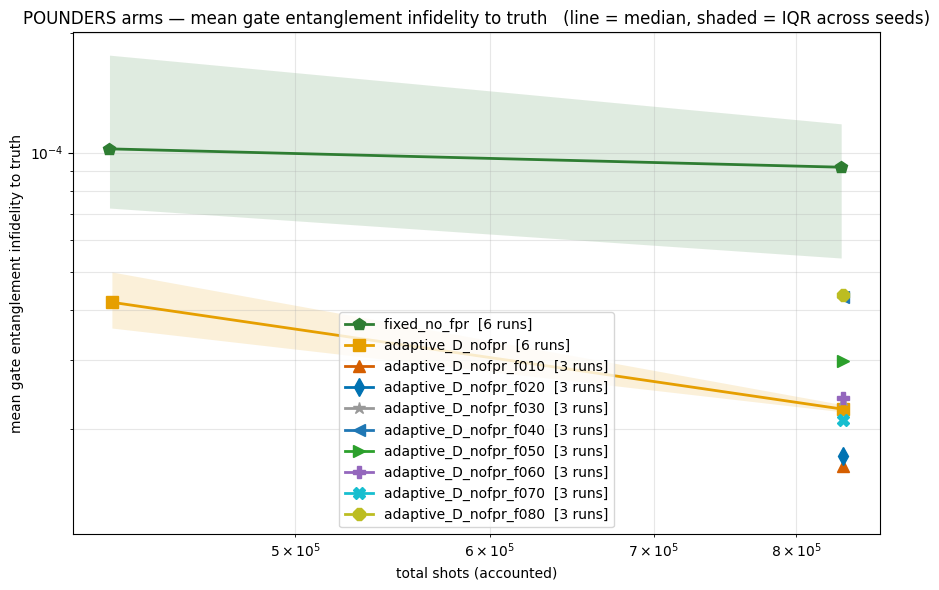

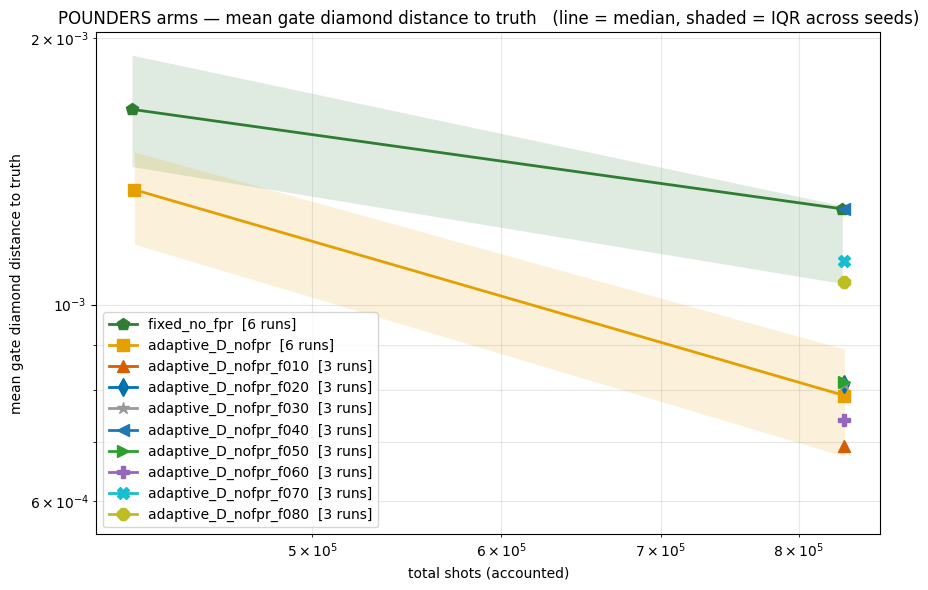

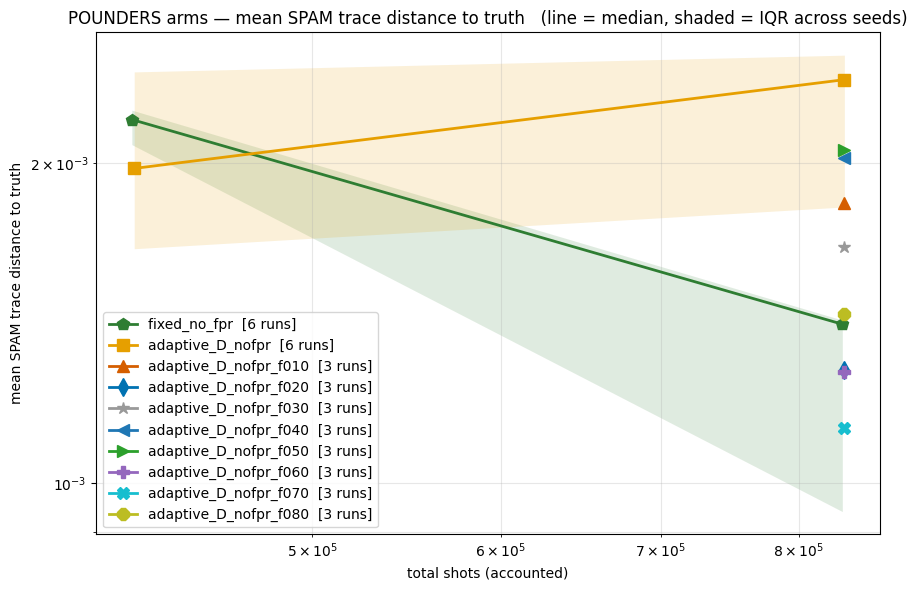

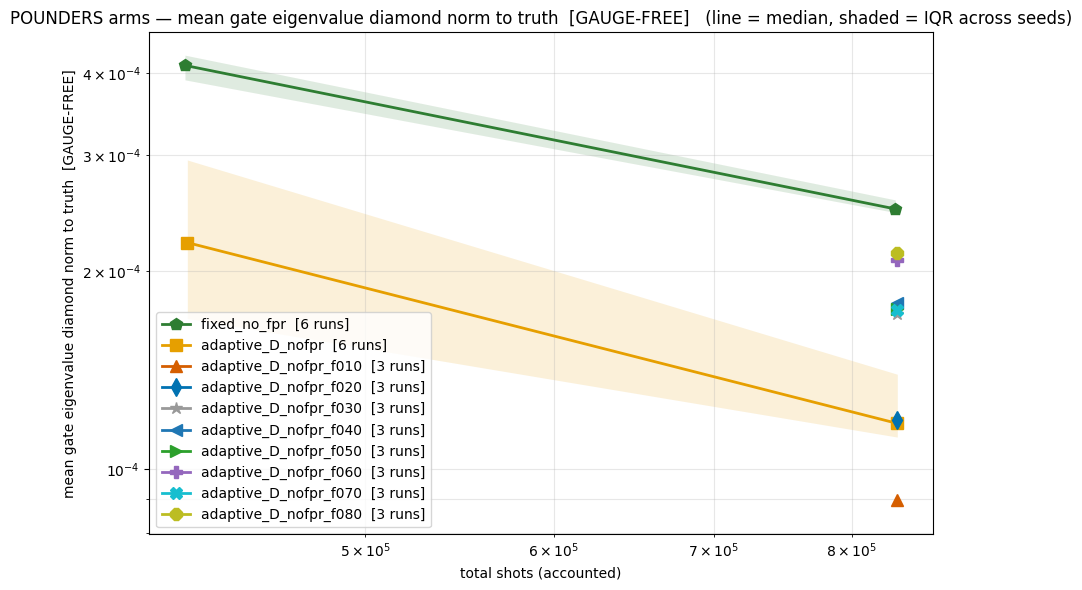

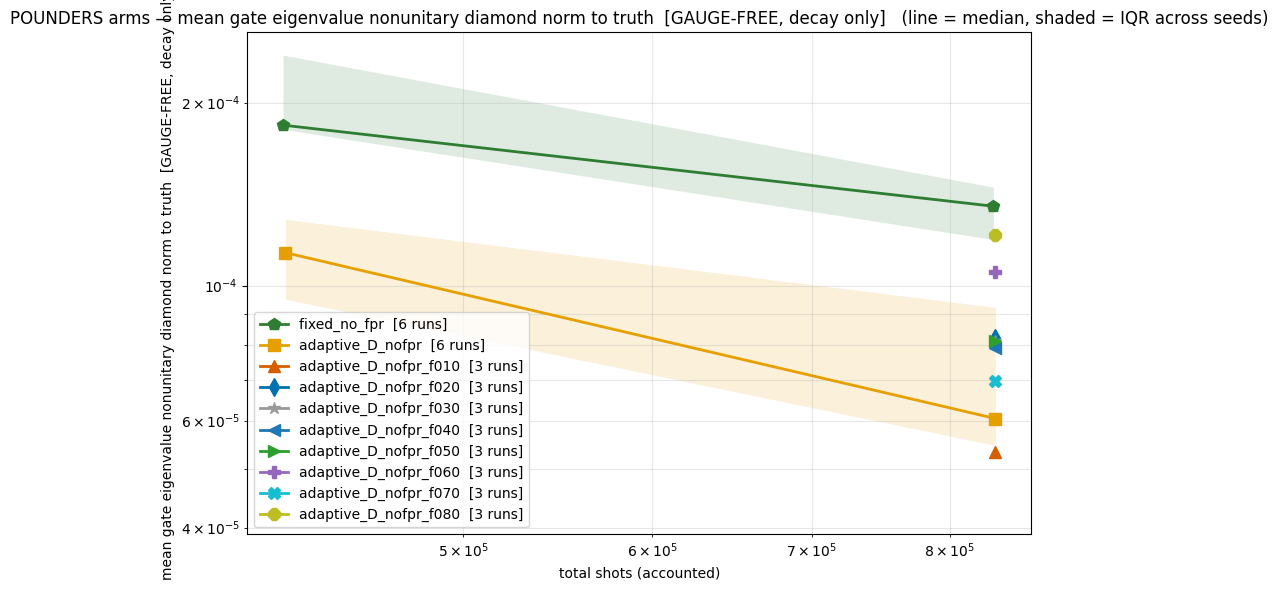

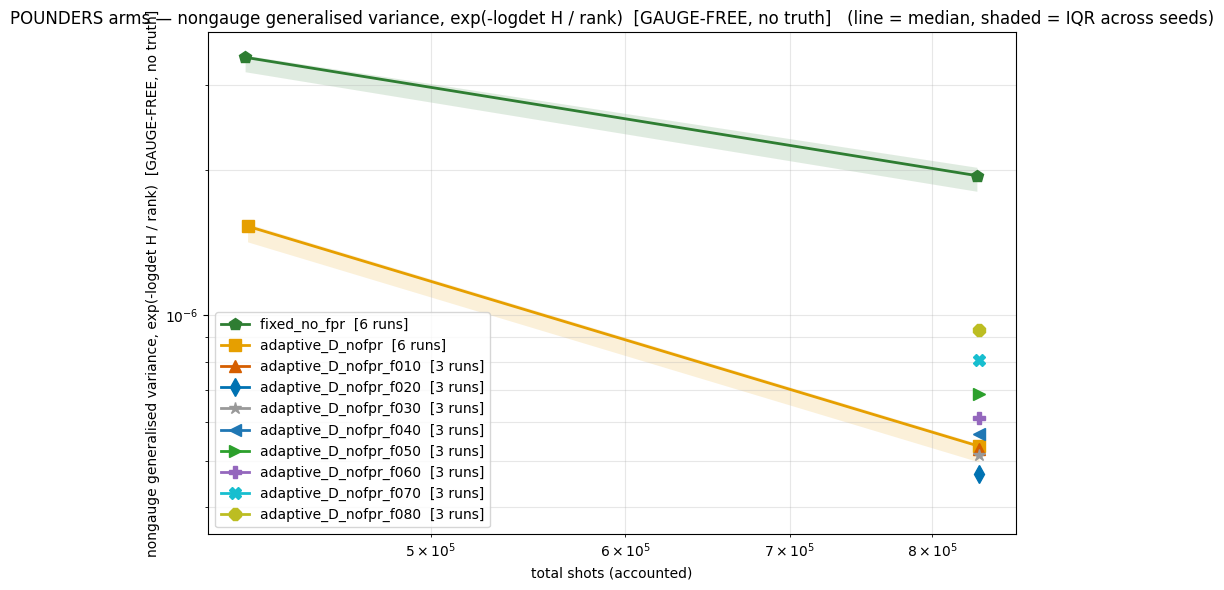

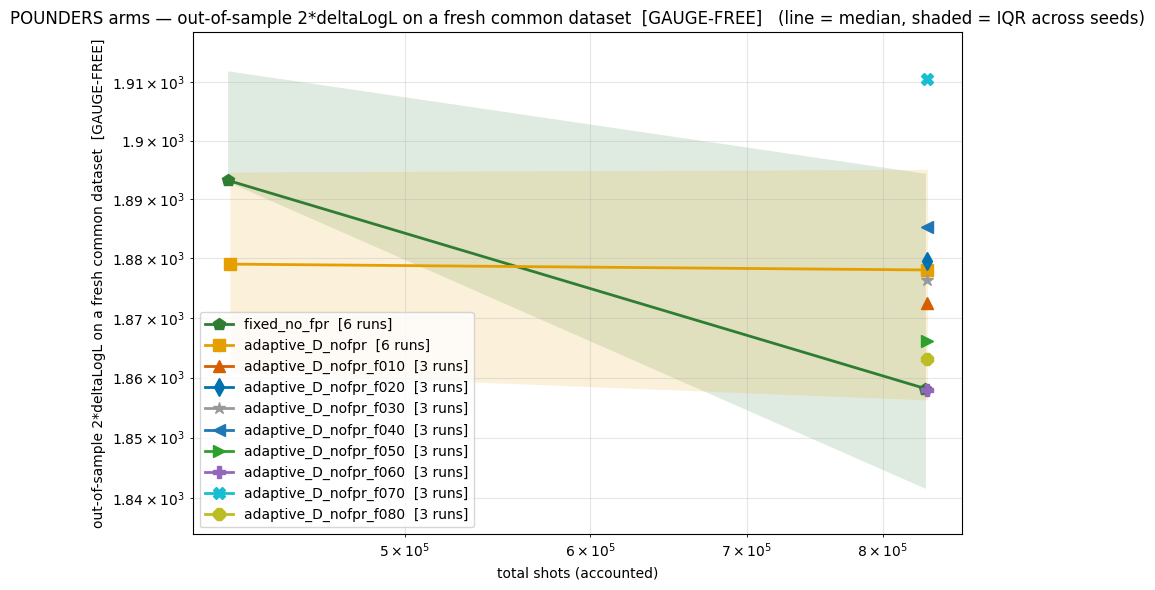

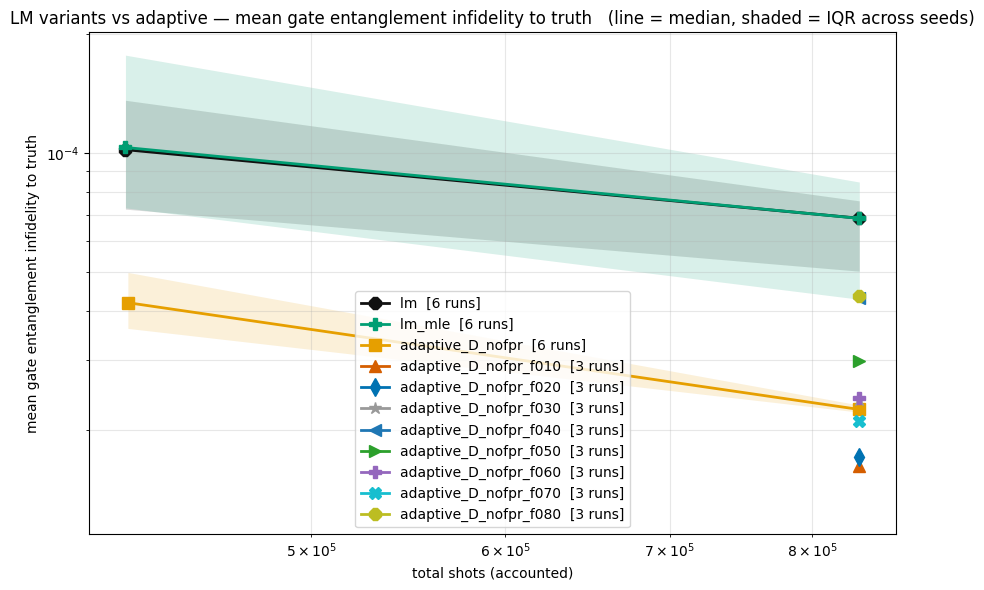

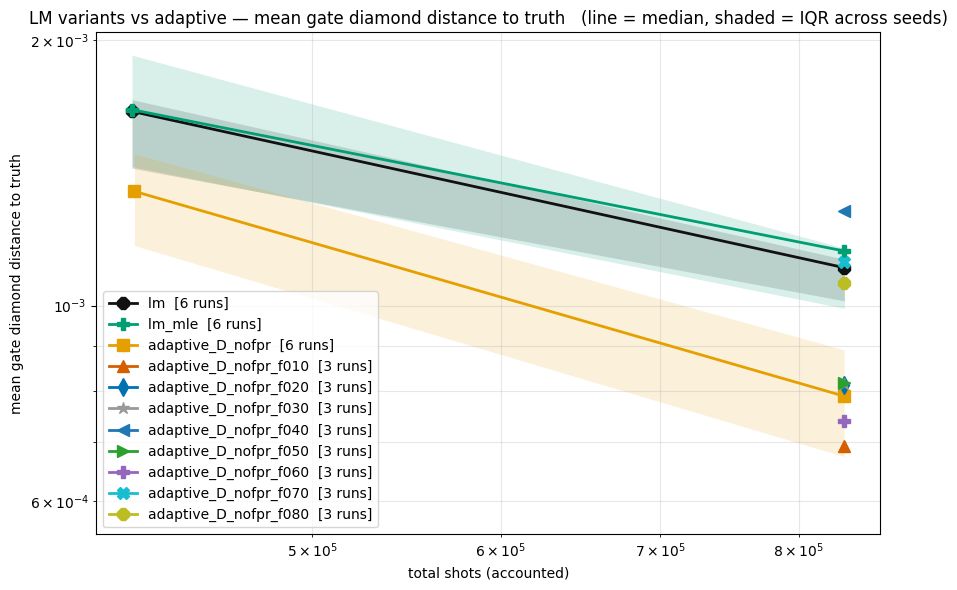

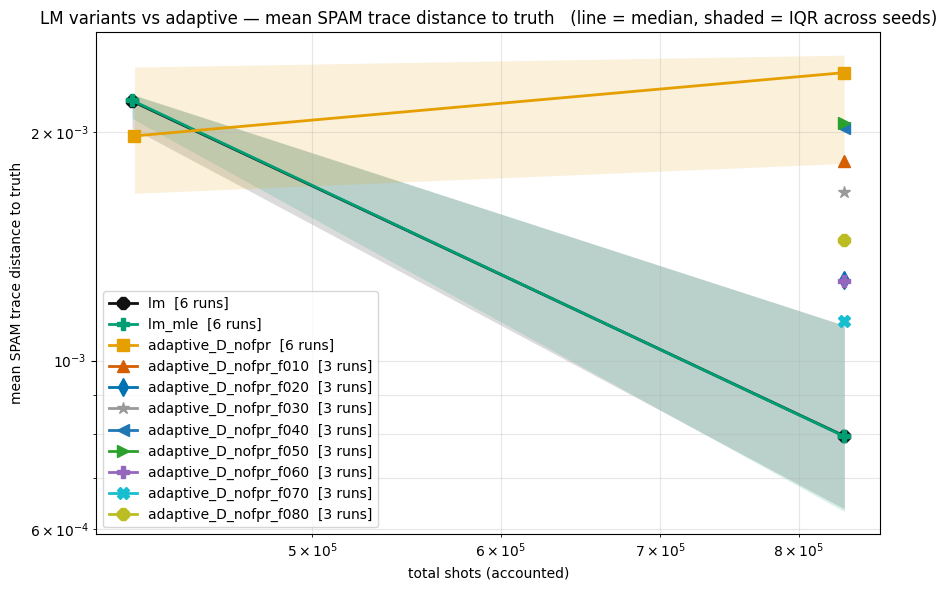

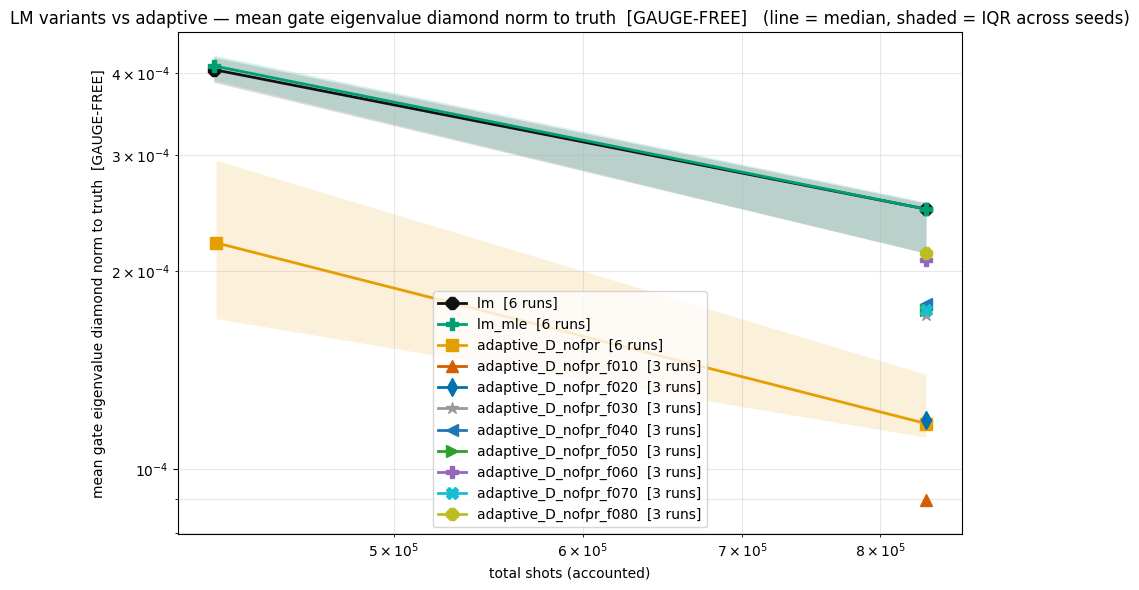

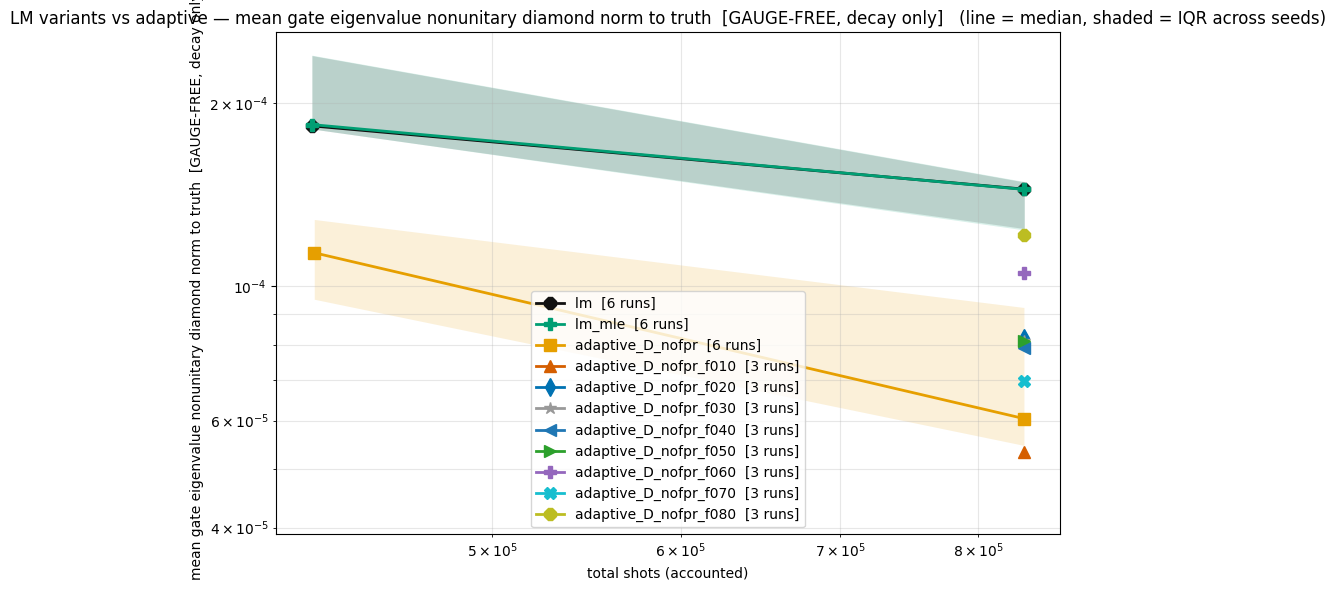

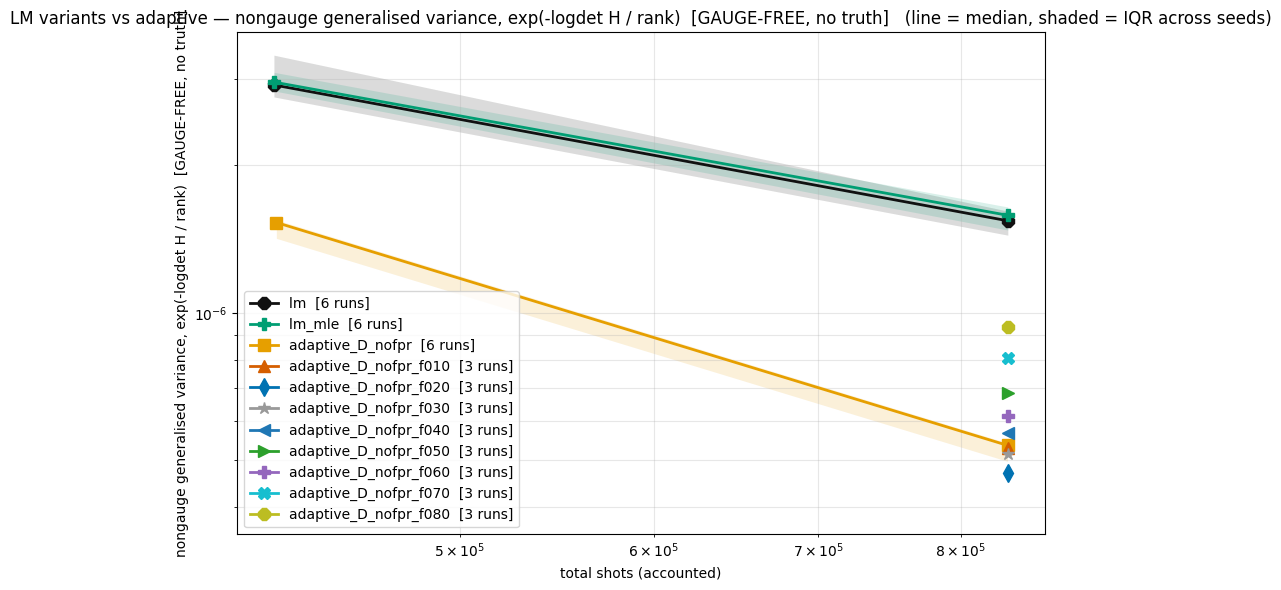

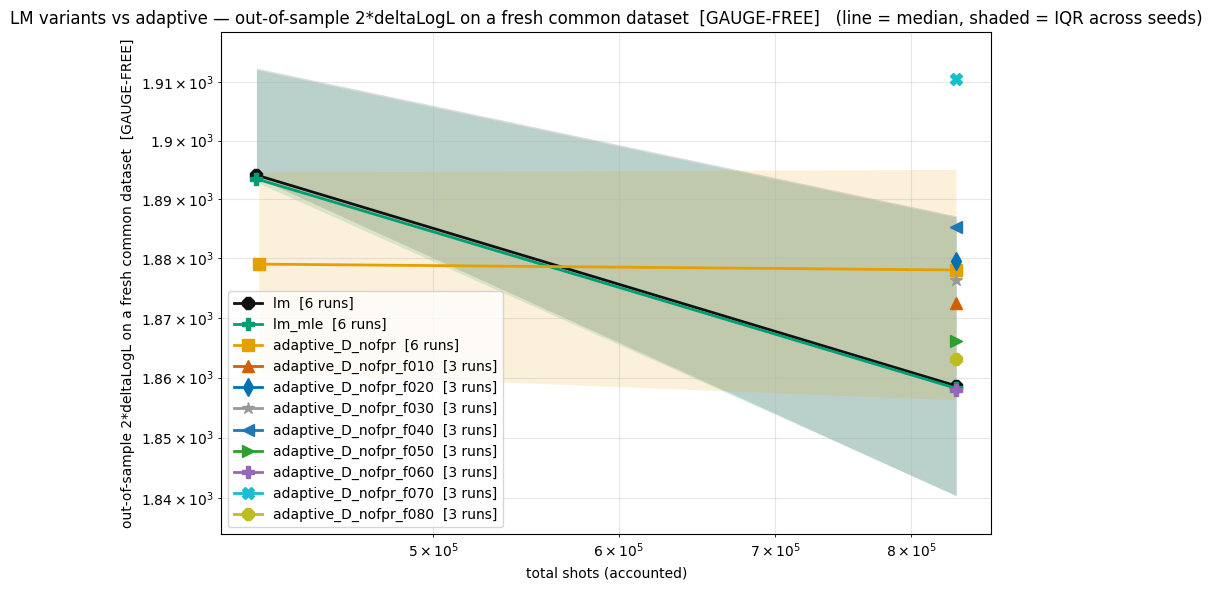

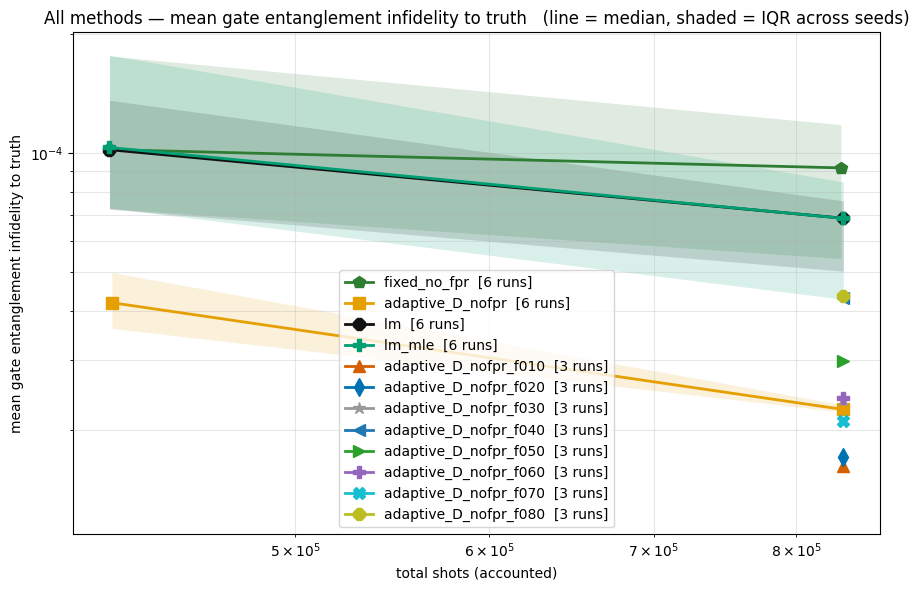

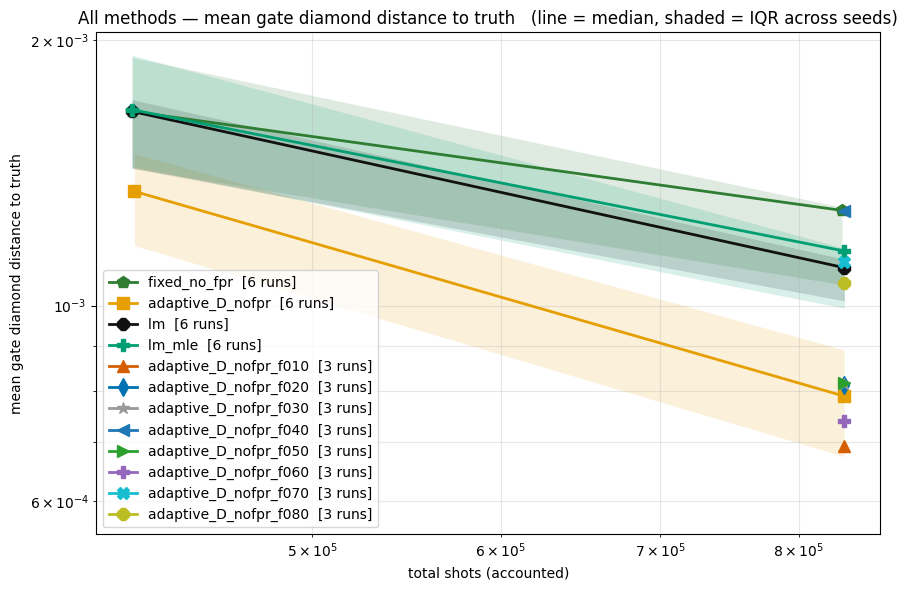

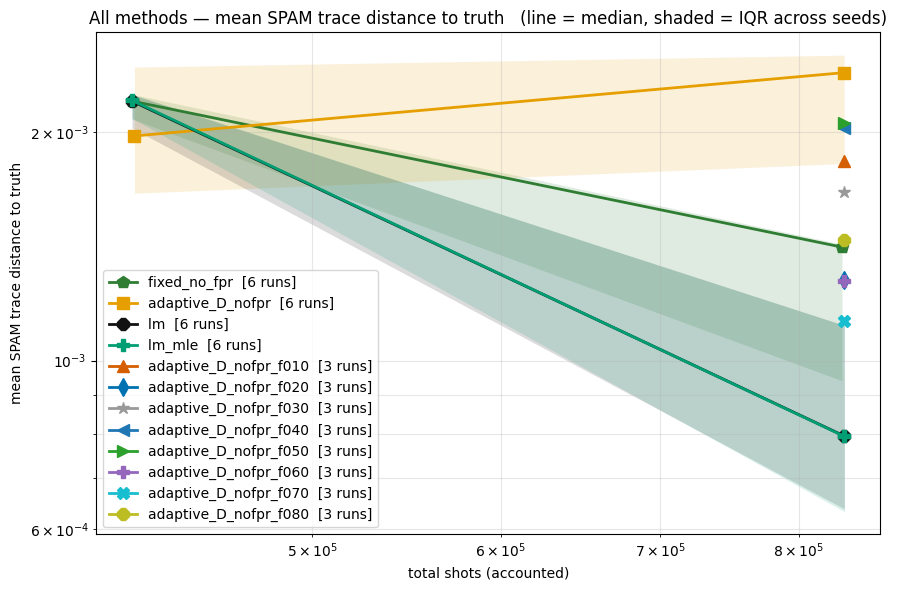

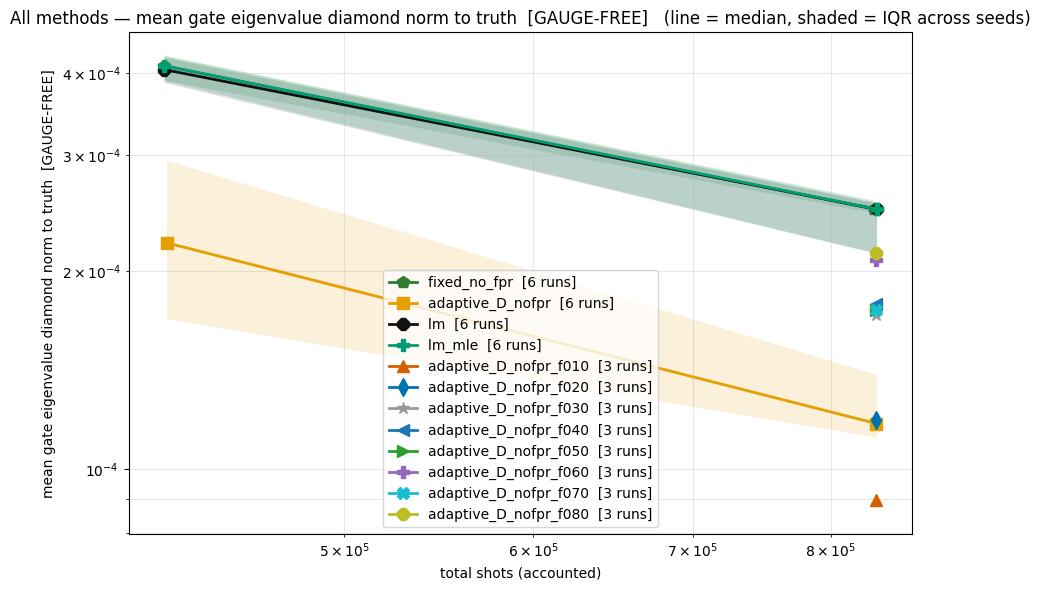

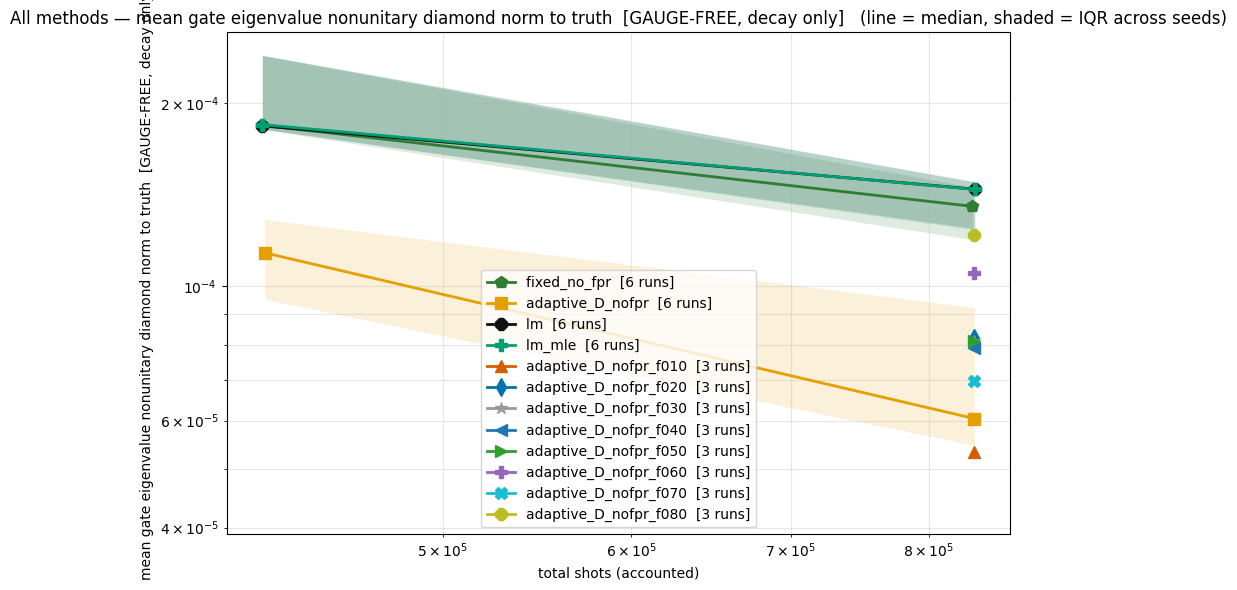

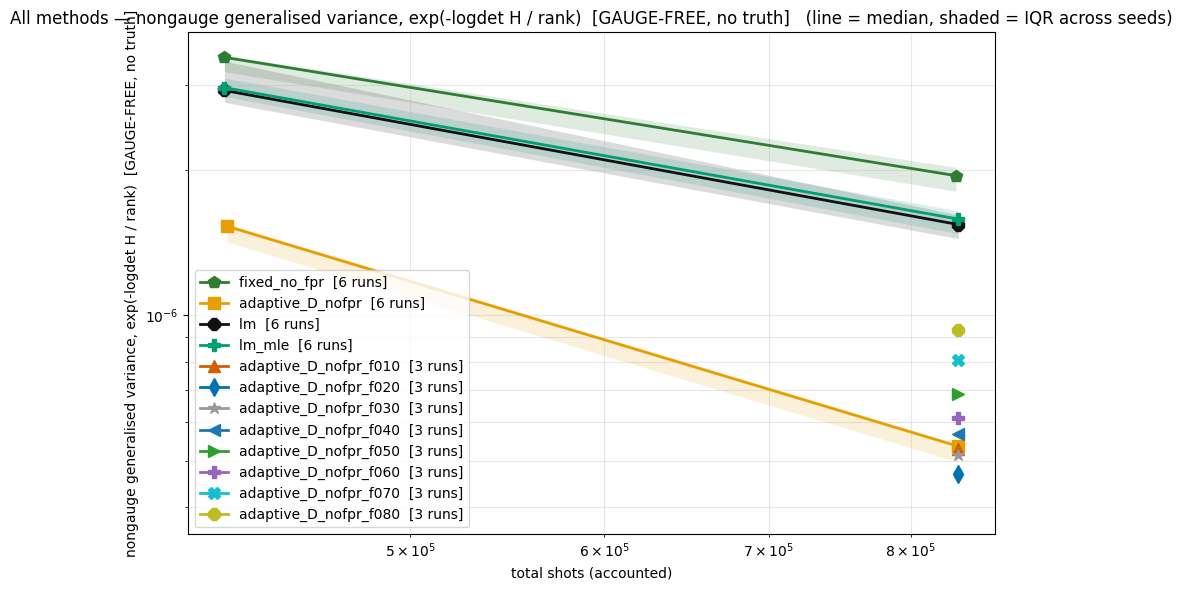

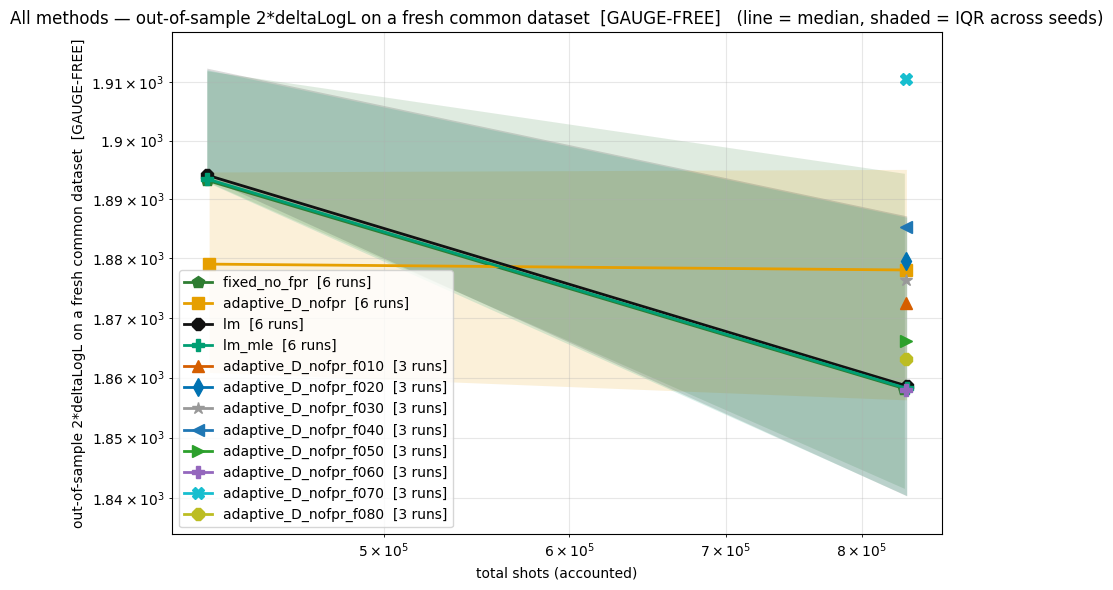

figures written to /workspace/IBCDFO/GST_POUNDERS/seed_sweep_experiments

median mean gate entanglement infidelity to truth by budget
method                       adaptive_D_nofpr  adaptive_D_nofpr_f010  adaptive_D_nofpr_f020  adaptive_D_nofpr_f030  adaptive_D_nofpr_f040  adaptive_D_nofpr_f050  adaptive_D_nofpr_f060  adaptive_D_nofpr_f070  adaptive_D_nofpr_f080  fixed_no_fpr        lm    lm_mle
run                                                                                                                                                                                                                                                                    
all_methods_comparison_1000         2.250e-05              1.622e-05              1.710e-05              2.372e-05              4.312e-05              2.981e-05              2.408e-05              2.108e-05              4.357e-05     9.185e-05 6.850e-05 6.844e-05
all_methods_comparison_500          4.189e-05                    NaN      

In [30]:
# Colours/markers keyed on the ARM FOLDER NAME, which is what `method` holds.
STYLE = {"fixed_no_fpr": ("#2E7D32", "p"), "fixed_fpr": ("#7F3C00", "h"),
         "adaptive_D": ("#B00068", "o"), "adaptive_A": ("#56B4E9", "D"),
         "adaptive_L": ("#CC79A7", "v"),
         "lm": ("#111111", "8"), "lm_mle": ("#009E73", "P"), "lm_fpr": ("#0072B2", "X")}
_SPARE = [("#E69F00", "s"), ("#D55E00", "^"), ("#0072B2", "d"), ("#999999", "*"),
          ("#1F77B4", "<"), ("#2CA02C", ">"), ("#9467BD", "P"), ("#17BECF", "X"),
          ("#BCBD22", "8"), ("#E377C2", "H")]
for _i, _m in enumerate(sorted(set(df["method"]) - set(STYLE))):
    STYLE[_m] = _SPARE[_i % len(_SPARE)]

# The first three are computed after gaugeopt and so depend on gaugeopt_spam_weight; the
# last two do not depend on any gauge choice. See the "Gauge-free metrics" section above.
METRICS = (("infidelity", "mean gate entanglement infidelity to truth"),
           ("diamond",    "mean gate diamond distance to truth"),
           # Trace distance, not the L2 norm on superket coefficients: L2 is
           # basis-dependent and bounds nothing an experiment could measure, whereas the
           # trace distance IS the largest probability difference any measurement could
           # produce. Both are still gauge-dependent -- SPAM has no invariant form.
           ("spam_tracedist", "mean SPAM trace distance to truth"),
           ("ev_diamond", "mean gate eigenvalue diamond norm to truth  [GAUGE-FREE]"),
           ("ev_diamond_nu",
            "mean gate eigenvalue nonunitary diamond norm to truth  [GAUGE-FREE, decay only]"),
           # Estimator quality rather than distance-to-truth: neither needs a gauge, and
           # nongauge_gen_var needs no truth model either. Lower is better for both.
           ("nongauge_gen_var",
            "nongauge generalised variance, exp(-logdet H / rank)  [GAUGE-FREE, no truth]"),
           ("oos_2dlogl",
            "out-of-sample 2*deltaLogL on a fresh common dataset  [GAUGE-FREE]"))

# Spread around the median, across the seeds within each run folder.
#   "iqr"  - shaded 25th-75th percentile band (readable with several series overlapping)
#   "bars" - capped error bars at the same quartiles
#   "none" - median line only
# The quartiles are over as few as 3 seeds at some budgets, so read a narrow band as
# "few runs" rather than "precise". The legend carries the count per series.
SPREAD = "iqr"


def plot(methods, title, prefix, metrics=METRICS):
    """One figure per metric: median across seeds per run folder, versus accounted shots."""
    methods = [m for m in dict.fromkeys(methods) if m in set(df["method"])]
    for metric, ylabel in metrics:
        fig, ax = plt.subplots(figsize=(9, 6))
        drawn = False
        for m in methods:
            a = df[df["method"] == m].dropna(subset=[metric, "shots"])
            if a.empty:
                continue
            g = (a.groupby("run").agg(x=("shots", "median"), y=(metric, "median"),
                                      lo=(metric, lambda v: v.quantile(0.25)),
                                      hi=(metric, lambda v: v.quantile(0.75)),
                                      n=("seed", "nunique")).sort_values("x"))
            c, mk = STYLE.get(m, ("grey", "o"))
            if SPREAD == "iqr":
                ax.fill_between(g["x"], g["lo"], g["hi"], color=c, alpha=0.15, lw=0)
            elif SPREAD == "bars":
                ax.errorbar(g["x"], g["y"],
                            yerr=np.vstack([(g["y"] - g["lo"]).values,
                                            (g["hi"] - g["y"]).values]),
                            fmt="none", ecolor=c, elinewidth=1.2, capsize=4, alpha=0.75)
            ax.plot(g["x"], g["y"], color=c, marker=mk, ms=9, lw=2,
                    label=f"{m}  [{int(g['n'].sum())} runs]")
            drawn = True
        if not drawn:
            plt.close(fig)
            print(f"({title}: no data for {metric})")
            continue
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("total shots (accounted)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title} — {ylabel}"
                     + ("   (line = median, shaded = IQR across seeds)" if SPREAD == "iqr"
                        else "   (line = median, bars = IQR across seeds)" if SPREAD == "bars"
                        else "   (median across seeds)"))
        ax.grid(alpha=0.3, which="both")
        ax.legend()
        fig.tight_layout()
        fig.savefig(DIR / f"{prefix}_{metric}.png", dpi=150, bbox_inches="tight")
        plt.show()


# ---- arm discovery -------------------------------------------------------------------
# Groups are derived from whatever is on disk, so a new arm (adaptive_D_nofpr, adaptive_A,
# a second criterion, ...) is plotted without editing this cell. PREFERRED fixes the order
# of the arms that already existed; anything else is appended alphabetically.
PREFERRED = ["fixed_no_fpr", "fixed_fpr",
             "adaptive_D", "adaptive_D_nofpr", "adaptive_A", "adaptive_A_nofpr",
             "adaptive_L", "adaptive_L_nofpr",
             "lm", "lm_mle", "lm_fpr"]

def order(ms):
    ms = set(ms)
    head = [m for m in PREFERRED if m in ms]
    return head + sorted(ms - set(head))

ALL_ARMS = order(df["method"].dropna().unique())
LM_ARMS = [m for m in ALL_ARMS if m.startswith("lm")]
POUNDERS_ARMS = [m for m in ALL_ARMS if m not in LM_ARMS]
ADAPTIVE_ARMS = [m for m in POUNDERS_ARMS if m.startswith("adaptive")]
print("arms found:", ALL_ARMS)
print("  POUNDERS:", POUNDERS_ARMS)
print("  LM      :", LM_ARMS)

# 1. the POUNDERS arms on their own
plot(POUNDERS_ARMS, "POUNDERS arms", "all")

# 2. every LM baseline against every adaptive arm, at matched revealed shots.
#    lm      = pyGSTi defaults: chi2 up the max-length ladder, one dlogl at the end
#    lm_mle  = dlogl at every ladder stage, no chi2 warmup, full 1918-circuit design
#    lm_fpr  = the same dlogl fit on pyGSTi's static FPR design -- fewer circuits, more shots
#              each. Estimator matches lm_mle exactly, so the pair isolates the DESIGN.
#    adaptive_*_nofpr = adaptive allocation with the FPR reduction switched off, which
#              unbundles the allocation gain from the circuit-reduction loss.
plot(LM_ARMS + ADAPTIVE_ARMS, "LM variants vs adaptive", "cmp")

# 3. everything on one axis
plot(ALL_ARMS, "All methods", "every")

print("figures written to", DIR)


# ---- median table, one row per budget -------------------------------------------------
for metric, ylabel in METRICS:
    piv = df.pivot_table(index="run", columns="method", values=metric, aggfunc="median")
    if piv.dropna(how="all").empty:
        continue
    print(f"\nmedian {ylabel} by budget")
    print(piv.to_string(float_format=lambda v: f"{v:.3e}"))